# Reestimación C (entorno continuo)

## 1. Objetivo Real

Estimar C tal que ``reward_normalized = raw_reward / C`` y que:

* los rewards estén en una escala estable 
* no dependan de outliers
* sean comparables entre políticas

## 2. Estrategia 

Estimación usando varias políticas de referencia no entrenadas, porque si calculamos C con una sola política, puede quedar sesgado.
### Políticas empleadas:
 * **Aleatoria Uniforme.** Cobertura amplia del espacio de acción.
 * **Aleatoria centrada en 0.5.** Simula políticas conservadoras/casi neutras.
 * **Heurística simple.** Introduce una política con cierta lógica energética.

 ### Estadísticos empleados (para estimar C)
 Calculamos para el reward absoluto por paso |r_t| y usar como candidato principal el percentil 95 de |r_t| agregad de todas las trayectorias. Lo más defendible porque:

 * es robusto
 * no depende de un único outlier extremo,
 * garantiza que la mayoría de rewards queden en una escala manejable
 
 Como alternativas:
 * media de |r_t|
 * percentil 90
 * percentil 95
 * percentil 99 

 ## **IMPORTANTE:** estimar C con reward bruto, no con penalización ya metida

 Hacemos la estimación C sobre el reward bruto que devuelve mg.run(), es decir: raw_reward = mg_reward sin aplicar todavía:

 * escala natural del reward
 * intensidad relativa de la penalización

¿Por qué ? C debe capturar la escala económica base del entorno.
La penalización por batería baja la calibramos después respecto a esa escala.

Esto nos permite separar bien dos cosas: escala natural del reward, intensidad relativa de la penalización. Es mucho más limpio metodológicamente.


# Imports y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from pymgrid import Microgrid
from pymgrid import modules

from pathlib import Path

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# -----------------------------
# PATHS
# -----------------------------
ruta_script = Path.cwd()
ruta_pv = ruta_script / "data" / "processed" / "pv_generacion_corregida_kw.csv"
ruta_load = ruta_script / "data" / "raw" / "load" / "RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv"
ruta_price = ruta_script / "data" / "external" / "precio2025-peninsula.csv"

# -----------------------------
# CARGA DE DATOS
# -----------------------------
load_df = pd.read_csv(ruta_load)
pv_df = pd.read_csv(ruta_pv)
price_df = pd.read_csv(ruta_price, sep=";")

print("Load shape:", load_df.shape)
print("PV shape:", pv_df.shape)
print("Price shape:", price_df.shape)
print(pv_df.head())

Load shape: (8760, 1)
PV shape: (8760, 2)
Price shape: (8760, 6)
   irradiancia_wm2  pv_kw
0                0    0.0
1                0    0.0
2                0    0.0
3                0    0.0
4                0    0.0


# 1. Extraer series (y convertir precio)

In [3]:
# -----------------------------
# EXTRACCIÓN DE SERIES
# -----------------------------
load_series = load_df.iloc[:, 0].astype(float).to_numpy()
#pv_series = pv_df.iloc[:, 0].astype(float).to_numpy()
pv_series = pv_df["pv_kw"].to_numpy(dtype=float)

# Precio original en €/MWh -> convertir a €/kWh
price_series = price_df["value"].astype(float).to_numpy() / 1000.0

print("len(load_series):", len(load_series))
print("len(pv_series):", len(pv_series))
print("len(price_series):", len(price_series))

assert len(load_series) == 8760
assert len(pv_series) == 8760
assert len(price_series) == 8760

len(load_series): 8760
len(pv_series): 8760
len(price_series): 8760


In [4]:
#convertir a arrays 1D de float
price_series = np.asarray(price_series, dtype=float).reshape(-1)
load_series = np.asarray(load_series, dtype=float).reshape(-1)
pv_series = np.asarray(pv_series, dtype=float).reshape(-1)

# 2. Fijar rangos iniciales defendibles 

## Inspección de rangos

In [5]:
# -----------------------------
# INSPECCIÓN RÁPIDA
# -----------------------------
net_load_series = load_series - pv_series

print("LOAD")
print(" min:", load_series.min())
print(" max:", load_series.max())
print(" mean:", load_series.mean())

print("\nPV")
print(" min:", pv_series.min())
print(" max:", pv_series.max())
print(" mean:", pv_series.mean())

print("\nNET LOAD = load - pv")
print(" min:", net_load_series.min())
print(" max:", net_load_series.max())
print(" mean:", net_load_series.mean())

print("\nPRICE [€/kWh]")
print(" min:", price_series.min())
print(" max:", price_series.max())
print(" mean:", price_series.mean())

LOAD
 min: 14.59173151
 max: 70.39555915
 mean: 35.48129092019977

PV
 min: 0.0
 max: 75.0
 mean: 15.598124999999998

NET LOAD = load - pv
 min: -40.64014768
 max: 62.44468015
 mean: 19.883165920199772

PRICE [€/kWh]
 min: 0.0206
 max: 0.42314999999999997
 mean: 0.136445151826484


## Fijamos rangos 

In [6]:
# -----------------------------
# RANGOS INICIALES DEFENDIBLES
# -----------------------------
net_load_min = float(np.floor(net_load_series.min() / 5.0) * 5.0)
net_load_max = float(np.ceil(net_load_series.max() / 5.0) * 5.0)

price_min = 0.0
price_max = float(np.ceil(price_series.max() / 0.05) * 0.05)

print("net_load_min =", net_load_min)
print("net_load_max =", net_load_max)
print("price_min =", price_min)
print("price_max =", price_max)

net_load_min = -45.0
net_load_max = 65.0
price_min = 0.0
price_max = 0.45


In [7]:
net_load_series = load_series - pv_series

mean_load = load_series.mean()
max_load = load_series.max()

mean_net_load = net_load_series.mean()
max_net_load = net_load_series.max()
min_net_load = net_load_series.min()

In [8]:
battery_max_capacity = 3 * mean_load   # 3 horas de consumo medio
battery_max_charge = 0.5 * max_load
battery_max_discharge = 0.5 * max_load

In [9]:
print(battery_max_capacity)
print(battery_max_charge)
print(battery_max_discharge)

106.4438727605993
35.197779575
35.197779575


# 3. Creamos microgrid

In [10]:
from pymgrid import Microgrid
from pymgrid.modules import LoadModule, RenewableModule, BatteryModule, GridModule

In [11]:
# -----------------------------
# VALIDACIONES BÁSICAS
# -----------------------------
assert len(load_series) == 8760
assert len(pv_series) == 8760
assert len(price_series) == 8760

assert np.isfinite(load_series).all()
assert np.isfinite(pv_series).all()
assert np.isfinite(price_series).all()

assert (load_series >= 0).all(), "La demanda no debería ser negativa"
assert (pv_series >= 0).all(), "La generación FV no debería ser negativa"

In [12]:
# lo que asumiamos en nuestro entorno: export_price = 0.5 * import_price
export_price_series = 0.5 * price_series

In [13]:
ts_load = pd.DataFrame({"load": load_series})
ts_load.head()

,load
0,22.321537
1,14.644444
2,14.664632
3,14.676162
4,14.826450


In [14]:
ts_pv = pd.DataFrame({"pv": pv_series})
ts_pv.head()

,pv
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [15]:
# -----------------------------
# PARÁMETROS FÍSICOS DE EJEMPLO
# -----------------------------
battery_min_capacity = 10.0
battery_max_capacity = 120.0
battery_max_charge = 35.0
battery_max_discharge = 35.0
battery_efficiency = 0.90
battery_init_soc = 0.50

grid_max_import = float(np.ceil(1.10 * load_series.max() / 5.0) * 5.0)
grid_max_export = float(np.ceil(1.10 * pv_series.max() / 5.0) * 5.0)
print(grid_max_export)
print(grid_max_import)

85.0
80.0


In [16]:
# -----------------------------
# MÓDULOS DE LA MICRORED
# -----------------------------
load_module = LoadModule(
    time_series=load_series,
    raise_errors=False
)

pv_module = RenewableModule(
    time_series=pv_series,
)

battery_module = BatteryModule(
    min_capacity=battery_min_capacity,
    max_capacity=battery_max_capacity,
    max_charge=battery_max_charge,
    max_discharge=battery_max_discharge,
    efficiency=battery_efficiency,
    init_soc=battery_init_soc,
)


In [17]:
grid_ts = pd.DataFrame({
    "import_price": price_series,
    "export_price": export_price_series,
    "co2_per_kwh": np.zeros_like(price_series),
})
display(grid_ts.head())
print(grid_ts.shape)

,import_price,export_price,co2_per_kwh
0,0.18279,0.091395,0.0
1,0.18319,0.091595,0.0
2,0.18874,0.094370,0.0
3,0.18777,0.093885,0.0
4,0.18019,0.090095,0.0


(8760, 3)


In [18]:
grid_module = GridModule(
    max_import=grid_max_import,
    max_export=grid_max_export,
    time_series=grid_ts
)

In [19]:
# -----------------------------
# CONSTRUCCIÓN DE LA MICRORED
# -----------------------------
# -----------------------------
# MICROGRID
# -----------------------------
mg = Microgrid(
    [
        ("load", load_module),
        ("pv", pv_module),
        ("battery", battery_module),
        ("grid", grid_module),
    ],
    add_unbalanced_module=True,
    loss_load_cost=10.0,
    overgeneration_cost=1.0,
)



In [20]:
#Verificaciones
mg.reset()

print("len(mg):", len(mg))
print("load actual:", mg.modules.load.item().current_load)
print("pv actual:", mg.pv.item().current_renewable)
print("soc actual:", mg.battery.item().soc)
print("import price actual:", mg.grid.item().import_price[0])
print("export price actual:", mg.grid.item().export_price[0])

obs, reward, done, info = mg.run(
    {"battery": [0.5], "grid": [0.5]},
    normalized=True
)

print("reward ejemplo:", reward)
print("done:", done)
print("info:", info)

len(mg): 8760
load actual: 14.64444443
pv actual: 0.0
soc actual: 0.5
import price actual: 0.18319
export price actual: 0.091595
reward ejemplo: -208.15990124444446
done: False
info: {'load': [('absorbed_energy', 14.64444443)], 'battery': [('absorbed_energy', 3.694444444444443)], 'grid': [('absorbed_energy', 2.5), ('co2_production', 0.0)], 'pv': [('provided_energy', 0.0), ('curtailment', 0.0)], 'balancing': [('provided_energy', np.float64(20.838888874444443))]}


# 4. Instanciación del entorno

In [21]:
from custom_env_continuous import CustomEnvContinuous

In [22]:
env = CustomEnvContinuous(
    pymgrid_network=mg,
    horizon=24 * 365,
    reward_scale_C=1.0,     # temporalmente 1.0
    low_soc_penalty=0.0,    # sin penalización todavía
    low_soc_threshold=0.05,
    net_load_min=net_load_min,
    net_load_max=net_load_max,
    price_min=price_min,
    price_max=price_max,
)

### Comprobación rápida del entorno

In [23]:
obs, info = env.reset()

print("obs inicial:", obs)
print("info inicial:", info)

action = np.array([0.5], dtype=np.float32)
obs, reward, terminated, truncated, info = env.step(action)

print("\nobs tras step:", obs)
print("reward devuelto por env:", reward)
print("mg_reward en info:", info["mg_reward"])
print("terminated:", terminated)
print("truncated:", truncated)
print("soc_after:", info["soc_after"])
print("low_soc_penalty_applied:", info["low_soc_penalty_applied"])

obs inicial: [0.08444444 0.52770835 0.40708888 0.         1.         0.
 1.        ]
info inicial: {'current_step': 0, 'current_load': 14.64444443, 'current_pv': 0.0, 'current_import_price': 0.18319, 'current_export_price': 0.091595, 'soc': 0.5277083333333333}

obs tras step: [0.08481149 0.55541664 0.4194222  0.25881904 0.9659258  0.
 1.        ]
reward devuelto por env: -208.15990124444446
mg_reward en info: -208.15990124444446
terminated: False
truncated: False
soc_after: 0.5554166666666666
low_soc_penalty_applied: 0.0


# 6. Builder del entorno
## Aseguramos que cada rollout empiece limpio

In [24]:
def build_microgrid(load_series, pv_series, price_series):
    from pymgrid import Microgrid
    from pymgrid.modules import LoadModule, RenewableModule, BatteryModule, GridModule

    export_price_series = 0.5 * price_series

    grid_ts = pd.DataFrame({
        "import_price": price_series,
        "export_price": export_price_series,
        "co2_per_kwh": np.zeros_like(price_series),
    })

    load_module = LoadModule(time_series=load_series)

    pv_module = RenewableModule(time_series=pv_series)

    battery_module = BatteryModule(
        min_capacity=10.0,
        max_capacity=120.0,
        max_charge=35.0,
        max_discharge=35.0,
        efficiency=0.90,
        init_soc=0.50
    )

    grid_module = GridModule(
        max_import=85.0,
        max_export=80.0,
        time_series=grid_ts
    )

    mg = Microgrid(
        [
            ("load", load_module),
            ("pv", pv_module),
            ("battery", battery_module),
            ("grid", grid_module),
        ],
        add_unbalanced_module=True,
        loss_load_cost=10.0,
        overgeneration_cost=1.0,
    )

    return mg

In [25]:
def build_env():
    mg = build_microgrid(load_series, pv_series, price_series)

    env = CustomEnvContinuous(
        pymgrid_network=mg,
        horizon=24 * 365,
        reward_scale_C=1.0,   # SIN escalar
        low_soc_penalty=0.0,  # SIN penalización
        low_soc_threshold=0.05,
        net_load_min=net_load_min,
        net_load_max=net_load_max,
        price_min=price_min,
        price_max=price_max,
    )
    return env

# 7. Estimacion de C

## Políticas empleadas

In [26]:
def policy_uniform(obs, rng):
    return np.array([rng.uniform(0.0, 1.0)], dtype=np.float32)

In [27]:
def policy_centered(obs, rng):
    a = rng.normal(loc=0.5, scale=0.15)
    a = np.clip(a, 0.0, 1.0)
    return np.array([a], dtype=np.float32)

In [28]:
def policy_heuristic(obs, rng):
    net_load, soc, price, *_ = obs

    if price > 0.7 and soc > 0.3:
        a = 0.85   # descargar
    elif price < 0.3 and soc < 0.8:
        a = 0.15   # cargar
    elif net_load < -0.3 and soc < 0.9:
        a = 0.2    # cargar con excedente
    else:
        a = 0.5

    return np.array([a], dtype=np.float32)

## Recolección de rewards

In [29]:
def collect_raw_rewards(policy_fn, n_episodes=5, seed=123):
    rng = np.random.default_rng(seed)
    raw_rewards = []

    for ep in range(n_episodes):
        env = build_env()
        obs, _ = env.reset()

        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = policy_fn(obs, rng)
            obs, reward, terminated, truncated, info = env.step(action)

            raw_rewards.append(float(info["mg_reward"]))

    return np.array(raw_rewards)

## Ejecutar políticas 

In [30]:
raw_uniform = collect_raw_rewards(policy_uniform, n_episodes=5, seed=1)
raw_centered = collect_raw_rewards(policy_centered, n_episodes=5, seed=2)
raw_heuristic = collect_raw_rewards(policy_heuristic, n_episodes=5, seed=3)

raw_all = np.concatenate([raw_uniform, raw_centered, raw_heuristic])
abs_raw = np.abs(raw_all)

## Cálculos de C

In [31]:
raw_uniform = collect_raw_rewards(policy_uniform, n_episodes=5, seed=1)
raw_centered = collect_raw_rewards(policy_centered, n_episodes=5, seed=2)
raw_heuristic = collect_raw_rewards(policy_heuristic, n_episodes=5, seed=3)

raw_all = np.concatenate([raw_uniform, raw_centered, raw_heuristic])
abs_raw = np.abs(raw_all)

C_mean = float(np.mean(abs_raw))
C_p90 = float(np.percentile(abs_raw, 90))
C_p95 = float(np.percentile(abs_raw, 95))
C_p99 = float(np.percentile(abs_raw, 99))

print("C_mean =", C_mean)
print("C_p90  =", C_p90)
print("C_p95  =", C_p95)
print("C_p99  =", C_p99)

C_mean = 216.13030204793185
C_p90  = 434.1266916999999
C_p95  = 507.43869982771434
C_p99  = 670.2530282343773


In [32]:
#Validación útil
C_selected = C_p95
normalized_rewards = raw_all / C_selected

print("Normalized reward stats:")
print("min :", normalized_rewards.min())
print("max :", normalized_rewards.max())
print("mean:", normalized_rewards.mean())
print("std :", normalized_rewards.std())

Normalized reward stats:
min : -1.870368770494522
max : -0.00010149009134992126
mean: -0.4259239630743821
std : 0.3421846559911308


# 8. Cálculo con otro enfoque 
## Politica heuristica ligeramente cambiada
## Más steps
## Recolectamos más informacion

In [44]:
def policy_heuristic(obs, rng):
    net_load_norm = obs[0]
    soc = obs[1]
    price_norm = obs[2]

    # Excedente FV -> cargar
    if net_load_norm < -0.2:
        a = 0.15

    # Precio alto y batería disponible -> descargar
    elif price_norm > 0.7 and soc > 0.2:
        a = 0.85

    # Precio bajo -> cargar algo si hay margen
    elif price_norm < 0.3 and soc < 0.9:
        a = 0.25

    # En otro caso, comportamiento casi neutro
    else:
        a = 0.5

    return np.array([a], dtype=np.float32)

In [34]:
def rollout_policy(env, policy_fn, n_episodes=10, seed=123):
    rng = np.random.default_rng(seed)

    all_step_rewards = []
    episode_returns = []
    all_actions = []
    all_socs = []
    all_costs = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            action = policy_fn(obs, rng)
            next_obs, reward, terminated, truncated, info = env.step(action)

            # reward = raw_reward porque reward_scale_C=1 y low_soc_penalty=0
            all_step_rewards.append(float(info["mg_reward"]))
            all_actions.append(float(action[0]))
            all_socs.append(float(info["soc"]))
            all_costs.append(float(info["cost"]))

            ep_return += float(info["mg_reward"])
            obs = next_obs
            done = terminated or truncated

        episode_returns.append(ep_return)

    return {
        "step_rewards": np.array(all_step_rewards, dtype=float),
        "episode_returns": np.array(episode_returns, dtype=float),
        "actions": np.array(all_actions, dtype=float),
        "socs": np.array(all_socs, dtype=float),
        "costs": np.array(all_costs, dtype=float),
    }

In [35]:
results_uniform = rollout_policy(env, policy_uniform, n_episodes=10, seed=123)
results_centered = rollout_policy(env, policy_centered, n_episodes=10, seed=456)
results_heuristic = rollout_policy(env, policy_heuristic, n_episodes=10, seed=789)

In [36]:
def summarize_rewards(name, rewards):
    abs_rewards = np.abs(rewards)

    summary = {
        "policy": name,
        "n_steps": len(rewards),
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_abs_reward": np.mean(abs_rewards),
        "median_abs_reward": np.median(abs_rewards),
        "p90_abs_reward": np.percentile(abs_rewards, 90),
        "p95_abs_reward": np.percentile(abs_rewards, 95),
        "p99_abs_reward": np.percentile(abs_rewards, 99),
        "max_abs_reward": np.max(abs_rewards),
    }
    return summary

In [37]:
all_rewards = np.concatenate([
    results_uniform["step_rewards"],
    results_centered["step_rewards"],
    results_heuristic["step_rewards"]
])

abs_rewards = np.abs(all_rewards)

C_mean_abs = np.mean(abs_rewards)
C_median_abs = np.median(abs_rewards)
C_p90 = np.percentile(abs_rewards, 90)
C_p95 = np.percentile(abs_rewards, 95)
C_p99 = np.percentile(abs_rewards, 99)

print("C_mean_abs =", C_mean_abs)
print("C_median_abs =", C_median_abs)
print("C_p90 =", C_p90)
print("C_p95 =", C_p95)
print("C_p99 =", C_p99)

C_mean_abs = 256.2882303584082
C_median_abs = 248.8927133
C_p90 = 483.2680896
C_p95 = 555.3023775387963
C_p99 = 718.433753944543


In [38]:
C_selected = C_p95
print("C seleccionado =", C_selected)

C seleccionado = 555.3023775387963


In [39]:
normalized_rewards = all_rewards / C_selected

print("Reward normalizada:")
print(" mean =", normalized_rewards.mean())
print(" std =", normalized_rewards.std())
print(" min =", normalized_rewards.min())
print(" max =", normalized_rewards.max())
print(" p1  =", np.percentile(normalized_rewards, 1))
print(" p99 =", np.percentile(normalized_rewards, 99))

Reward normalizada:
 mean = -0.4614573174268052
 std = 0.3333861992584813
 min = -1.7593800341342467
 max = 0.0009525215835457963
 p1  = -1.2937703546827504
 p99 = 0.00042103187282619813


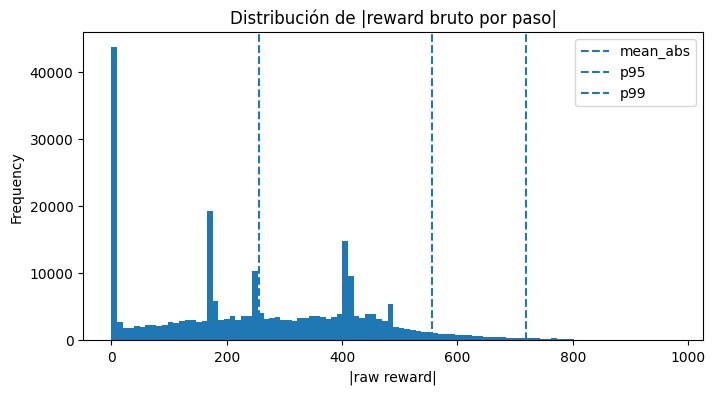

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(abs_rewards, bins=100)
plt.axvline(C_mean_abs, linestyle="--", label="mean_abs")
plt.axvline(C_p95, linestyle="--", label="p95")
plt.axvline(C_p99, linestyle="--", label="p99")
plt.xlabel("|raw reward|")
plt.ylabel("Frequency")
plt.title("Distribución de |reward bruto por paso|")
plt.legend()
plt.show()

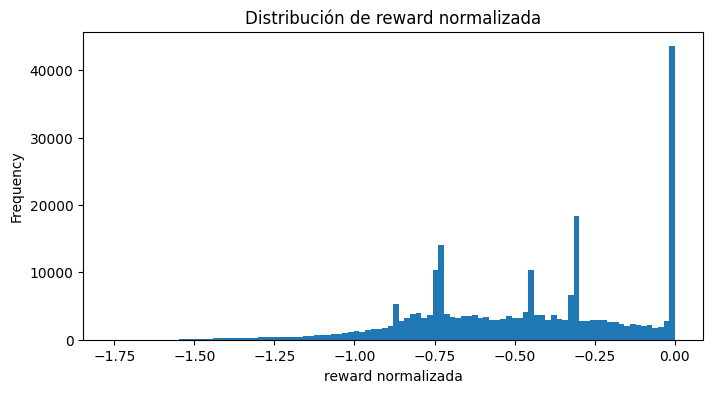

In [41]:
plt.figure(figsize=(8, 4))
plt.hist(normalized_rewards, bins=100)
plt.xlabel("reward normalizada")
plt.ylabel("Frequency")
plt.title("Distribución de reward normalizada")
plt.show()

# 9. Calibración de penalización por bateria baja

## Creamos entorno con C ya estimada

In [42]:
C_selected = 555.3

def build_env_with_penalty(low_soc_penalty):
    mg = build_microgrid(load_series, pv_series, price_series)

    env = CustomEnvContinuous(
        pymgrid_network=mg,
        horizon=24 * 365,
        reward_scale_C=C_selected,
        low_soc_penalty=low_soc_penalty,
        low_soc_threshold=0.05,
        net_load_min=net_load_min,
        net_load_max=net_load_max,
        price_min=price_min,
        price_max=price_max,
    )
    return env

## Función de evaluación 

In [53]:
def evaluate_penalty(policy_fn, low_soc_penalty, low_soc_threshold, n_episodes=5, seed=123):
    rng = np.random.default_rng(seed)

    base_rewards = []
    final_rewards = []
    penalties_applied = []
    socs = []

    low_soc_steps = 0
    total_steps = 0

    for ep in range(n_episodes):
        env = CustomEnvContinuous(
            pymgrid_network=build_microgrid(load_series, pv_series, price_series),
            horizon=24 * 365,
            reward_scale_C=C_selected,
            low_soc_penalty=low_soc_penalty,
            low_soc_threshold=low_soc_threshold,
            net_load_min=net_load_min,
            net_load_max=net_load_max,
            price_min=price_min,
            price_max=price_max,
        )

        obs, _ = env.reset()
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = policy_fn(obs, rng)
            obs, reward, terminated, truncated, info = env.step(action)

            base_reward = float(info["mg_reward"]) / C_selected
            penalty = float(info["low_soc_penalty_applied"])
            soc = info["soc"]

            base_rewards.append(base_reward)
            final_rewards.append(float(reward))
            penalties_applied.append(penalty)

            if soc is not None:
                socs.append(float(soc))
                if soc < low_soc_threshold:
                    low_soc_steps += 1

            total_steps += 1

    base_rewards = np.array(base_rewards, dtype=float)
    final_rewards = np.array(final_rewards, dtype=float)
    penalties_applied = np.array(penalties_applied, dtype=float)
    socs = np.array(socs, dtype=float) if len(socs) > 0 else np.array([], dtype=float)

    return {
        "low_soc_penalty": low_soc_penalty,
        "low_soc_threshold": low_soc_threshold,
        "n_steps": total_steps,
        "low_soc_step_ratio": low_soc_steps / total_steps if total_steps > 0 else 0.0,
        "mean_base_reward": base_rewards.mean(),
        "mean_final_reward": final_rewards.mean(),
        "mean_penalty_applied": penalties_applied.mean(),
        "max_penalty_applied": penalties_applied.max() if len(penalties_applied) else 0.0,
        "penalty_nonzero_ratio": np.mean(penalties_applied > 0),
        "mean_abs_base_reward": np.mean(np.abs(base_rewards)),
        "penalty_vs_mean_abs_base": (
            penalties_applied.mean() / np.mean(np.abs(base_rewards))
            if np.mean(np.abs(base_rewards)) > 0 else 0.0
        ),
        "min_soc": socs.min() if len(socs) else None,
        "mean_soc": socs.mean() if len(socs) else None,
    }

## Evaluamos candidatas

In [54]:
penalties = [0.10, 0.20, 0.30]
low_soc_threhold=0.05

for p in penalties:
    print(f"\n=== Penalty {p} | policy_uniform ===")
    print(evaluate_penalty(policy_uniform, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=1))

    print(f"\n=== Penalty {p} | policy_centered ===")
    print(evaluate_penalty(policy_centered, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=2))

    print(f"\n=== Penalty {p} | policy_heuristic ===")
    print(evaluate_penalty(policy_heuristic, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=3))


=== Penalty 0.1 | policy_uniform ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.05, 'n_steps': 43795, 'low_soc_step_ratio': 0.0, 'mean_base_reward': np.float64(-0.4161784349813315), 'mean_final_reward': np.float64(-0.4161784349813315), 'mean_penalty_applied': np.float64(0.0), 'max_penalty_applied': np.float64(0.0), 'penalty_nonzero_ratio': np.float64(0.0), 'mean_abs_base_reward': np.float64(0.4161784349813315), 'penalty_vs_mean_abs_base': np.float64(0.0), 'min_soc': np.float64(0.08333333333333333), 'mean_soc': np.float64(0.6464850387878306)}

=== Penalty 0.1 | policy_centered ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.05, 'n_steps': 43795, 'low_soc_step_ratio': 0.0, 'mean_base_reward': np.float64(-0.38257881832608087), 'mean_final_reward': np.float64(-0.38257881832608087), 'mean_penalty_applied': np.float64(0.0), 'max_penalty_applied': np.float64(0.0), 'penalty_nonzero_ratio': np.float64(0.0), 'mean_abs_base_reward': np.float64(0.38257881832608087), 'penalty_vs_mean_abs_

## Repetimos analisis

In [55]:
C_selected = 555.3

def build_env_with_penalty(low_soc_penalty):
    mg = build_microgrid(load_series, pv_series, price_series)

    env = CustomEnvContinuous(
        pymgrid_network=mg,
        horizon=24 * 365,
        reward_scale_C=C_selected,
        low_soc_penalty=low_soc_penalty,
        low_soc_threshold=0.10,
        net_load_min=net_load_min,
        net_load_max=net_load_max,
        price_min=price_min,
        price_max=price_max,
    )
    return env

In [56]:
penalties = [0.10, 0.20, 0.30]
low_soc_threhold=0.10

for p in penalties:
    print(f"\n=== Penalty {p} | policy_uniform ===")
    print(evaluate_penalty(policy_uniform, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=1))

    print(f"\n=== Penalty {p} | policy_centered ===")
    print(evaluate_penalty(policy_centered, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=2))

    print(f"\n=== Penalty {p} | policy_heuristic ===")
    print(evaluate_penalty(policy_heuristic, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=3))


=== Penalty 0.1 | policy_uniform ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.1, 'n_steps': 43795, 'low_soc_step_ratio': 0.06601210183810938, 'mean_base_reward': np.float64(-0.4161784349813315), 'mean_final_reward': np.float64(-0.4172303627381219), 'mean_penalty_applied': np.float64(0.001051927756790295), 'max_penalty_applied': np.float64(0.016666666666666677), 'penalty_nonzero_ratio': np.float64(0.06601210183810938), 'mean_abs_base_reward': np.float64(0.4161784349813315), 'penalty_vs_mean_abs_base': np.float64(0.002527588333204918), 'min_soc': np.float64(0.08333333333333333), 'mean_soc': np.float64(0.6464850387878306)}

=== Penalty 0.1 | policy_centered ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.1, 'n_steps': 43795, 'low_soc_step_ratio': 0.0013471857517981505, 'mean_base_reward': np.float64(-0.38257881832608087), 'mean_final_reward': np.float64(-0.3825977627104472), 'mean_penalty_applied': np.float64(1.8944384366400385e-05), 'max_penalty_applied': np.float64(0.0166666

In [57]:
C_selected = 555.3

def build_env_with_penalty(low_soc_penalty):
    mg = build_microgrid(load_series, pv_series, price_series)

    env = CustomEnvContinuous(
        pymgrid_network=mg,
        horizon=24 * 365,
        reward_scale_C=C_selected,
        low_soc_penalty=low_soc_penalty,
        low_soc_threshold=0.15,
        net_load_min=net_load_min,
        net_load_max=net_load_max,
        price_min=price_min,
        price_max=price_max,
    )
    return env

In [58]:
penalties = [0.10, 0.20, 0.30]
low_soc_threhold=0.15

for p in penalties:
    print(f"\n=== Penalty {p} | policy_uniform ===")
    print(evaluate_penalty(policy_uniform, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=1))

    print(f"\n=== Penalty {p} | policy_centered ===")
    print(evaluate_penalty(policy_centered, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=2))

    print(f"\n=== Penalty {p} | policy_heuristic ===")
    print(evaluate_penalty(policy_heuristic, p, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=3))


=== Penalty 0.1 | policy_uniform ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.15, 'n_steps': 43795, 'low_soc_step_ratio': 0.0863797237127526, 'mean_base_reward': np.float64(-0.4161784349813315), 'mean_final_reward': np.float64(-0.41941292197752716), 'mean_penalty_applied': np.float64(0.0032344869961955826), 'max_penalty_applied': np.float64(0.04444444444444445), 'penalty_nonzero_ratio': np.float64(0.0863797237127526), 'mean_abs_base_reward': np.float64(0.4161784349813315), 'penalty_vs_mean_abs_base': np.float64(0.007771875533004664), 'min_soc': np.float64(0.08333333333333333), 'mean_soc': np.float64(0.6464850387878306)}

=== Penalty 0.1 | policy_centered ===
{'low_soc_penalty': 0.1, 'low_soc_threshold': 0.15, 'n_steps': 43795, 'low_soc_step_ratio': 0.0027628724740267154, 'mean_base_reward': np.float64(-0.38257881832608087), 'mean_final_reward': np.float64(-0.38265827827943516), 'mean_penalty_applied': np.float64(7.945995335434027e-05), 'max_penalty_applied': np.float64(0.044444

In [60]:
C_selected = 555.3
low_soc_threhold=0.05

def build_env_with_penalty(low_soc_penalty):
    mg = build_microgrid(load_series, pv_series, price_series)

    env = CustomEnvContinuous(
        pymgrid_network=mg,
        horizon=24 * 365,
        reward_scale_C=C_selected,
        low_soc_penalty=low_soc_penalty,
        low_soc_threshold=0.05,
        net_load_min=net_load_min,
        net_load_max=net_load_max,
        price_min=price_min,
        price_max=price_max,
    )
    return env

In [61]:
print(f"\n=== Penalty {0.3} | policy_uniform ===")
print(evaluate_penalty(policy_uniform, 0.3, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=1))

print(f"\n=== Penalty {0.3} | policy_centered ===")
print(evaluate_penalty(policy_centered, 0.3, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=2))

print(f"\n=== Penalty {0.3} | policy_heuristic ===")
print(evaluate_penalty(policy_heuristic, 0.3, low_soc_threshold=low_soc_threhold, n_episodes=5, seed=3))


=== Penalty 0.3 | policy_uniform ===
{'low_soc_penalty': 0.3, 'low_soc_threshold': 0.05, 'n_steps': 43795, 'low_soc_step_ratio': 0.0, 'mean_base_reward': np.float64(-0.4161784349813315), 'mean_final_reward': np.float64(-0.4161784349813315), 'mean_penalty_applied': np.float64(0.0), 'max_penalty_applied': np.float64(0.0), 'penalty_nonzero_ratio': np.float64(0.0), 'mean_abs_base_reward': np.float64(0.4161784349813315), 'penalty_vs_mean_abs_base': np.float64(0.0), 'min_soc': np.float64(0.08333333333333333), 'mean_soc': np.float64(0.6464850387878306)}

=== Penalty 0.3 | policy_centered ===
{'low_soc_penalty': 0.3, 'low_soc_threshold': 0.05, 'n_steps': 43795, 'low_soc_step_ratio': 0.0, 'mean_base_reward': np.float64(-0.38257881832608087), 'mean_final_reward': np.float64(-0.38257881832608087), 'mean_penalty_applied': np.float64(0.0), 'max_penalty_applied': np.float64(0.0), 'penalty_nonzero_ratio': np.float64(0.0), 'mean_abs_base_reward': np.float64(0.38257881832608087), 'penalty_vs_mean_abs_